In [5]:
import numpy as np
import matplotlib.pyplot as plt

## Raw Simulation of Phenomenological Model

0.15


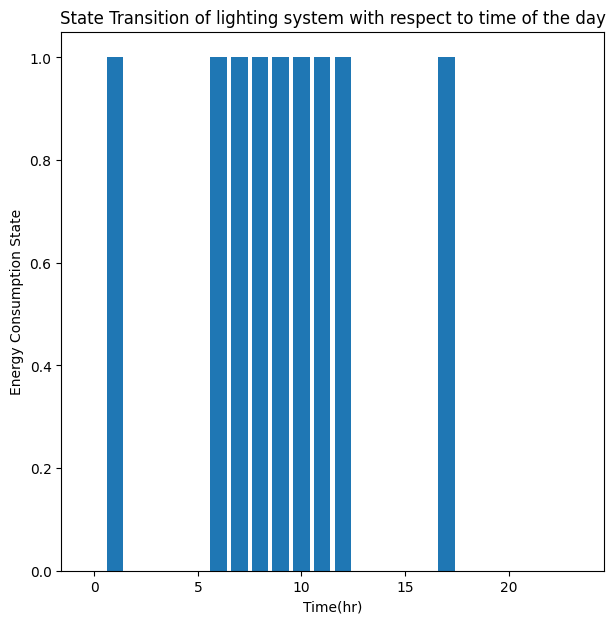

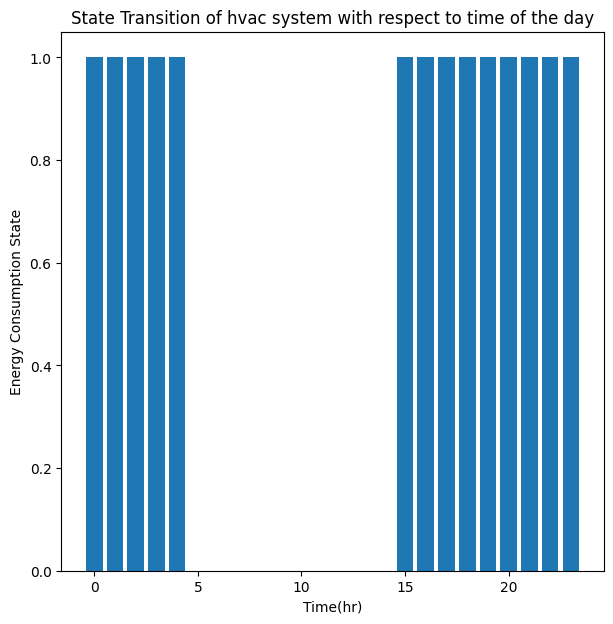

In [13]:
# considering transition for lighting and HVAC system
P_lighting = np.array([[0.85, 0.15],  # Night, mostly low energy with small chance for high energy
                       [0.20, 0.80]])  # Daytime, high occupancy, high energy stays dominant

P_hvac = np.array([[0.75, 0.25],  # Moderate temperature, low HVAC consumption
                   [0.30, 0.70]])  # High temperature, high HVAC consumption

# initialize states - low occupancy - low energy - non working hours
lighting_state = 0
# mild weather -> low hvac energy - non working hours and when occupancy is low
hvac_state = 0

# simulation for each hour in a day
T = 24

print(P_lighting[0,1])

# lighting and hvac system states
l_states =np.zeros(T)
hvac_states = np.zeros(T)

for i in range(T):
    lighting_state = np.random.choice([0,1],p=P_lighting[lighting_state])
    hvac_state = np.random.choice([0,1], p=P_hvac[hvac_state])

    l_states[i] = lighting_state
    hvac_states[i] = hvac_state

# plot for lighting
plt.figure(figsize=(7,7))
plt.bar([x for x in range(T)],l_states)
plt.title('State Transition of lighting system with respect to time of the day')
plt.xlabel('Time(hr)')
plt.ylabel('Energy Consumption State')
plt.show()

# plot for hvac
plt.figure(figsize=(7,7))
plt.bar([x for x in range(T)],hvac_states)
plt.title('State Transition of hvac system with respect to time of the day')
plt.xlabel('Time(hr)')
plt.ylabel('Energy Consumption State')
plt.show()



These plots do not simulate real life energy patterns in Industrial buildings. In our system we are going to consider a low occupancy level during the night time i.e 12 am - 7 am. Most industrial building get 7am to 6pm during the day.Hence, energy consumption for the lighting system will be high during these hours. Also occupancy pattern and time of the day affects the energy consumption in our HVAC system.

## Merging Mechanistic Model and Phenomenoligical Model

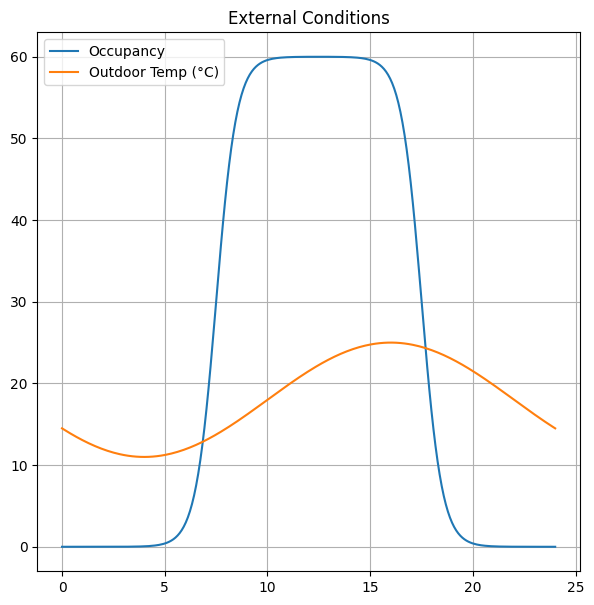

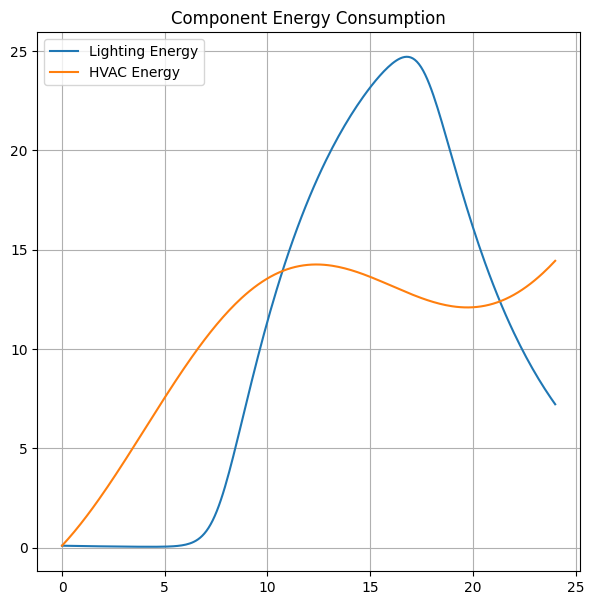

In [46]:
# defining occupancy function in relation to time

def occupancy(t,max_0):
    t = t % 24
    # Smoother transitions using sigmoid functions
    arrival = 1/(1 + np.exp(-2*(t-7.5)))    # Most arrive by 9AM
    departure = 1/(1 + np.exp(2*(t-17.5)))  # Most leave by 6PM
    return max_o * arrival * departure

def outdoor_temp(t, T_min=15, T_max=25):
    t = t % 24
    return 18 + 7*np.sin((t-10)*np.pi/12)  # Peaks at 4PM (10+6)


P_lighting = np.array([[0.85, 0.15],  # Night, mostly low energy with small chance for high energy
                       [0.20, 0.80]])  # Daytime, high occupancy, high energy stays dominant

P_hvac = np.array([[0.75, 0.25],  # Moderate temperature, low HVAC consumption
                   [0.20, 0.80]]) 

# defining constants
k1 = 0.1    # Lighting response to occupancy (kW/person)
k2 = 0.2  # Lighting decay rate (1/hours)
k3 = 0.15   # HVAC response to temp difference (kW/°C)
k4 = 0.08   # HVAC control efficiency (1/hours)
T_in = 22 
T= 24 #unit time in hours (considering a day)

dt = 0.1  

n_steps = int(T/dt)

# define maximum occupancy
max_o = 60

L_t = np.zeros(n_steps) #Lighting energy with time
H_t = np.zeros(n_steps) # HVAC energy with time
E_t = np.zeros(n_steps)
states_light = np.zeros(n_steps, dtype=int)
states_hvac = np.zeros(n_steps,dtype=int)

# define intial values for lighting and energy
L_t[0] = 0.1 
H_t[0] = 0.1 


# Initialize states - low occupancy, low energy, non-working hours
states_light[0] = 0  # Start in low energy state
states_hvac[0] = 0   # Start in low energy state


time = np.linspace(0,T,n_steps)

T_in = 22 #temperature in degrees celcius

for i in range(n_steps-1):
    # get current time
    t = time[i]
    # compute occupancy and outside temperature
    T_out = outdoor_temp(t)
    O_t = occupancy(t,max_o)

   
    states_light[i+1] = np.random.choice([0, 1], p=P_lighting[states_light[i]])
    
    # # Markov transitions for HVAC using np.random.choice
    # temp_state = 1 if T_out > 22 else 0  # Threshold for high HVAC state
    states_hvac[i+1] = np.random.choice([0, 1], p=P_hvac[states_hvac[i]])

    # computing rates
    dLdt = k1 * O_t - k2 * L_t[i] 
    dHdt = -k3 * (T_out - T_in) 

    # computing forward euler
    L_t[i+1] = L_t[i] + dLdt * dt
    H_t[i+1] = H_t[i] + dHdt * dt
    E_t[i+1] = L_t[i+1] + H_t[i+1]

# plot results
plt.figure(figsize=(7,7))
plt.plot(time, [occupancy(t,max_o) for t in time], label='Occupancy')
plt.plot(time, [outdoor_temp(t) for t in time], label='Outdoor Temp (°C)')
plt.title('External Conditions')
plt.legend()
plt.grid(True)
plt.show()

# # System States
# plt.figure(figsize=(7,7))
# plt.plot(time, states_light, label='Lighting State')
# plt.plot(time, states_hvac, label='HVAC State')
# plt.title('System States (0=Low, 1=High)')
# plt.legend()
# plt.grid(True)
# plt.show()

# Component Energy
plt.figure(figsize=(7,7))
plt.plot(time, L_t, label='Lighting Energy')
plt.plot(time, H_t, label='HVAC Energy')
plt.title('Component Energy Consumption')
plt.legend()
plt.grid(True)
plt.show()

    


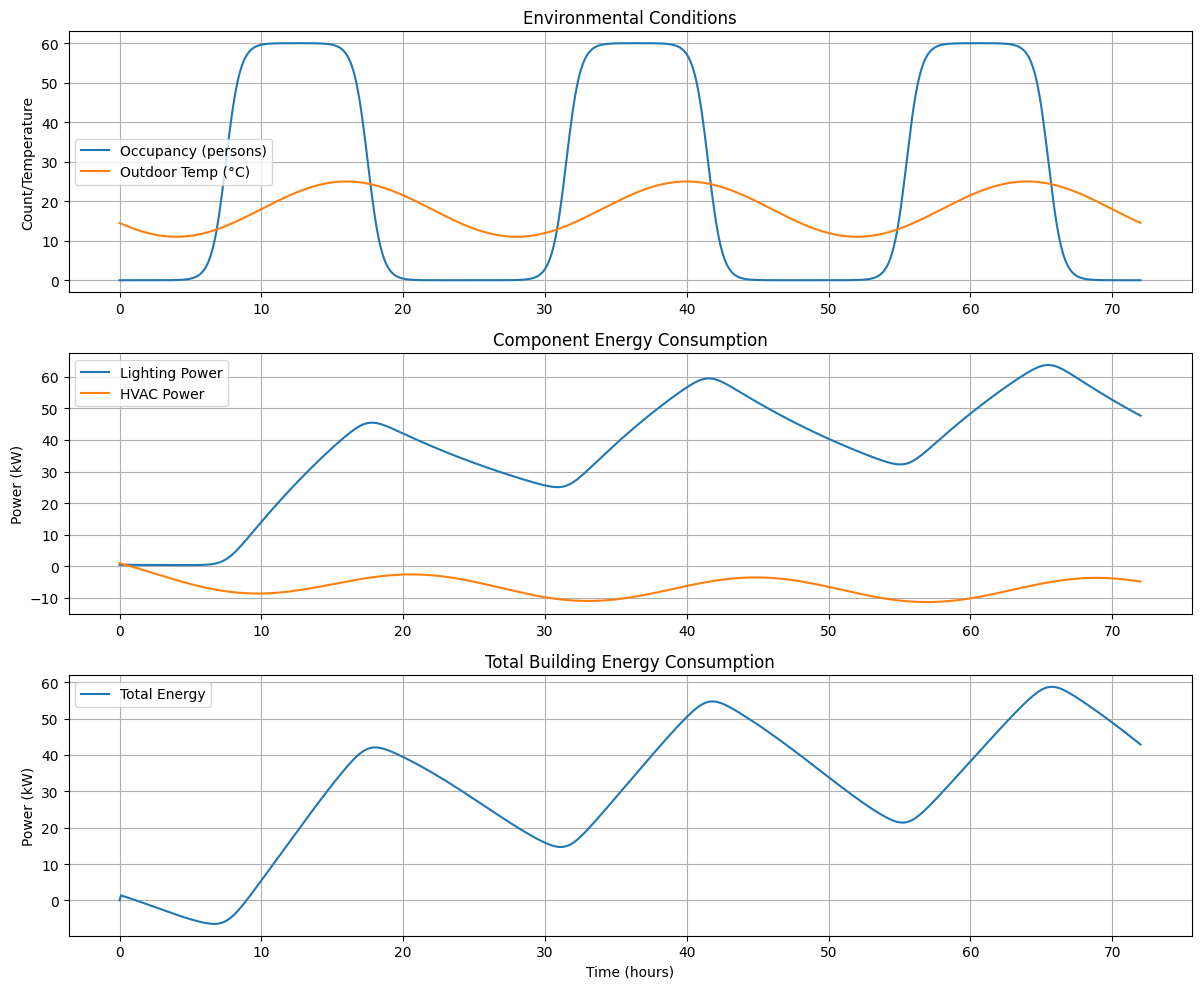

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Constants with physical meaning (now in proper units)
k1 = 0.1    # Lighting response to occupancy (kW/person)
k2 = 0.05   # Lighting decay rate (1/hours)
k3 = 0.15   # HVAC response to temp difference (kW/°C)
k4 = 0.08   # HVAC control efficiency (1/hours)
T_in = 22   # Indoor temperature setpoint (°C)

# Time parameters
T = 24*3    # Simulate for 3 days
dt = 0.1    # Time step (0.1 hours = 6 minutes)
n_steps = int(T/dt)
time = np.linspace(0, T, n_steps)

# Enhanced occupancy function
def occupancy(t, max_o=60):
    """Smooth occupancy profile with realistic transitions"""
    t = t % 24
    # Smoother transitions using sigmoid functions
    arrival = 1/(1 + np.exp(-2*(t-7.5)))    # Most arrive by 9AM
    departure = 1/(1 + np.exp(2*(t-17.5)))  # Most leave by 6PM
    return max_o * arrival * departure

# Improved outdoor temperature model
def outdoor_temp(t):
    """Sinusoidal temperature variation"""
    t = t % 24
    return 18 + 7*np.sin((t-10)*np.pi/12)  # Peaks at 4PM (10+6)

# Initialize arrays
L_t = np.zeros(n_steps)  # Lighting energy (kW)
H_t = np.zeros(n_steps)  # HVAC energy (kW)
E_t = np.zeros(n_steps)  # Total energy (kW)
occup = np.zeros(n_steps) # Occupancy tracking
temp_out = np.zeros(n_steps) # Temperature tracking

# Initial conditions
L_t[0] = 0.5  # Initial lighting (kW)
H_t[0] = 1.0  # Initial HVAC (kW)

# Forward Euler solution
for i in range(n_steps-1):
    t = time[i]
    
    # Current conditions
    occup[i] = occupancy(t)
    temp_out[i] = outdoor_temp(t)
    T_diff = temp_out[i] - T_in
    
    # Lighting ODE: dL/dt = k1*occupancy - k2*L
    dLdt = k1 * occup[i] - k2 * L_t[i]
    
    # HVAC ODE: dH/dt = k3*T_diff - k4*H
    dHdt = k3 * T_diff - k4 * H_t[i]
    
    # Forward Euler step
    L_t[i+1] = L_t[i] + dLdt * dt
    H_t[i+1] = H_t[i] + dHdt * dt
    E_t[i+1] = L_t[i+1] + H_t[i+1]

# Plotting results
plt.figure(figsize=(12, 10))

# Environmental conditions
plt.subplot(3, 1, 1)
plt.plot(time, [occupancy(t) for t in time], label='Occupancy (persons)')
plt.plot(time, [outdoor_temp(t) for t in time], label='Outdoor Temp (°C)')
plt.title('Environmental Conditions')
plt.ylabel('Count/Temperature')
plt.legend()
plt.grid(True)

# Component energy
plt.subplot(3, 1, 2)
plt.plot(time, L_t, label='Lighting Power')
plt.plot(time, H_t, label='HVAC Power')
plt.title('Component Energy Consumption')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(True)

# Total energy
plt.subplot(3, 1, 3)
plt.plot(time, E_t, label='Total Energy')
plt.title('Total Building Energy Consumption')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Reiterating Mechanistic Model

We can see from the above graphs that our mechanistic model does not simulate a realistic pattern of the two systems in an industrial building. Our energy is peaking above 20kW which is not the typical range for industrial buildings (0-20kW). Reiterating on our mechanistic model we incoorprate daylight in our lighting system and also factor in occupancy for HVAC system

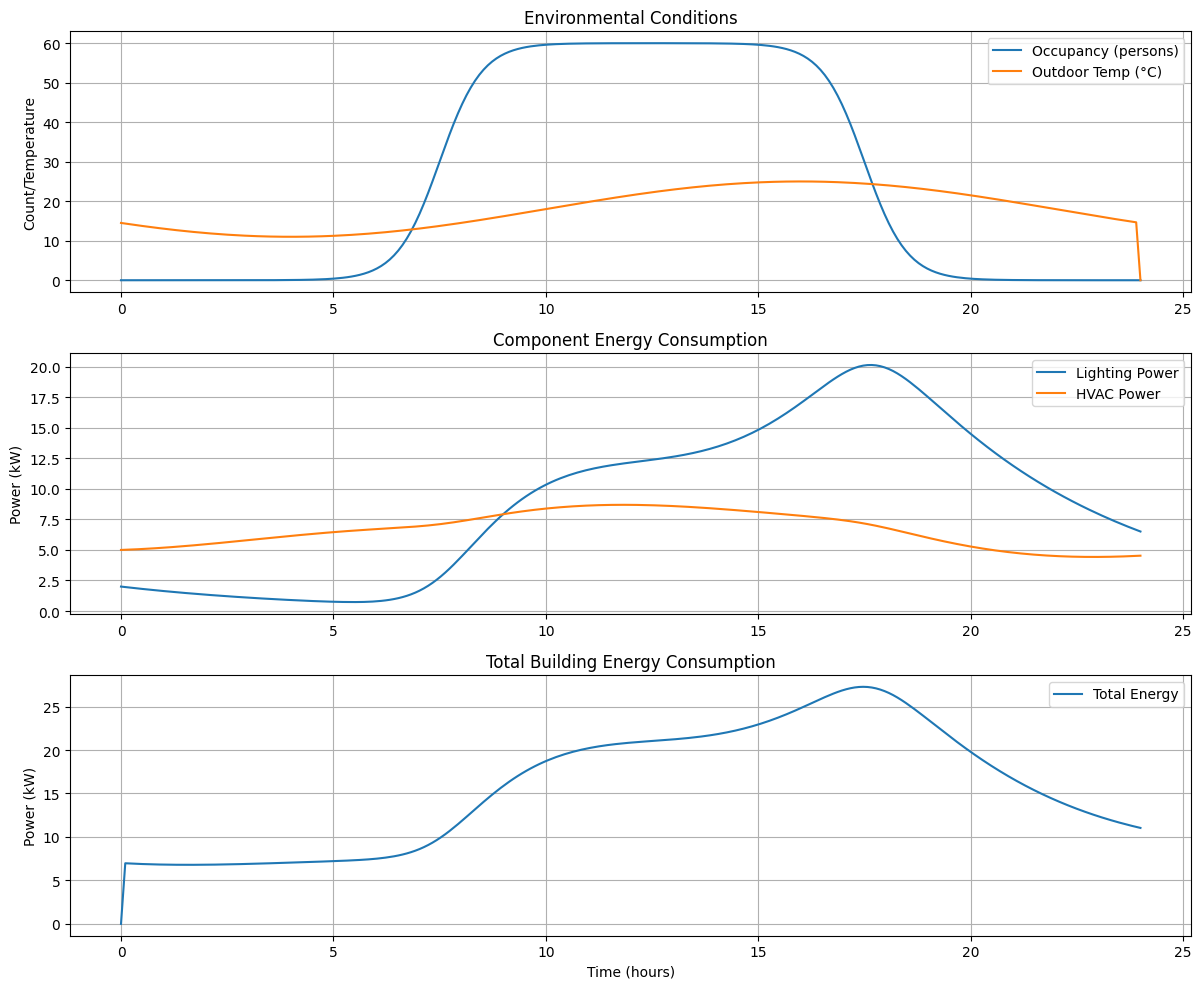

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
k1 = 0.08    # Lighting response to occupancy (kW/person)
k2 = 0.1     # Lighting decay rate (1/hours)
k3 = 0.12    # HVAC response to temp difference (kW/°C)
k4 = 0.15    # HVAC control efficiency (1/hours)
k5 = 0.02    # Additional HVAC load per person (kW/person)
T_in = 22    # Indoor temperature setpoint (°C)

# Time parameters (keeping your original setup)
T = 24     # Simulate for 3 days
dt = 0.1     # Time step (0.1 hours = 6 minutes)
n_steps = int(T/dt)
time = np.linspace(0, T, n_steps)

# Time constants for more realistic response
lighting_time_constant = 0.5  # hours
hvac_time_constant = 1.2      # hours

# Your original occupancy function with smoother transitions
def occupancy(t, max_o=60):
    t = t % 24
    arrival = 1/(1 + np.exp(-2*(t-7.5)))    # Most arrive by 9AM
    departure = 1/(1 + np.exp(2*(t-17.5)))   # Most leave by 6PM
    return max_o * arrival * departure

# Your original outdoor temp function with sinusoidal variation
def outdoor_temp(t):
    t = t % 24
    return 18 + 7*np.sin((t-10)*np.pi/12)  # Peaks at 4PM

# New daylight availability function
def daylight_availability(t):
    t = t % 24
    if 6 <= t <= 18:  # Daytime hours
        return 0.7 * np.sin((t-6)*np.pi/12)  # Peaks at noon
    return 0  # Night time

# Initialize arrays (your original variables)
L_t = np.zeros(n_steps)  # Lighting energy (kW)
H_t = np.zeros(n_steps)  # HVAC energy (kW)
E_t = np.zeros(n_steps)  # Total energy (kW)
occup = np.zeros(n_steps) # Occupancy tracking
temp_out = np.zeros(n_steps) # Temperature tracking

# Initial conditions (adjusted for realism)
L_t[0] = 2.0  # Initial lighting (kW)
H_t[0] = 5.0  # Initial HVAC (kW)

# Forward Euler solution (your original structure)
for i in range(n_steps-1):
    t = time[i]
    
    # Current conditions
    occup[i] = occupancy(t)
    temp_out[i] = outdoor_temp(t)
    daylight = daylight_availability(t)
    T_diff = temp_out[i] - T_in
    
    # Modified lighting ODE with daylight harvesting
    dLdt = (k1 * occup[i] * (1 - daylight) - k2 * L_t[i]) / lighting_time_constant
    
    # Modified HVAC ODE with occupancy effect
    dHdt = (-k3 * T_diff + k5 * occup[i] - k4 * H_t[i]) / hvac_time_constant
    
    # Your original forward Euler implementation
    L_t[i+1] = L_t[i] + dLdt * dt
    H_t[i+1] = H_t[i] + dHdt * dt
    E_t[i+1] = L_t[i+1] + H_t[i+1]

# Plotting (enhanced version of your original plots)
plt.figure(figsize=(12, 10))

# Environmental conditions
plt.subplot(3, 1, 1)
plt.plot(time, occup, label='Occupancy (persons)')
plt.plot(time, temp_out, label='Outdoor Temp (°C)')
plt.title('Environmental Conditions')
plt.ylabel('Count/Temperature')
plt.legend()
plt.grid(True)

# Component energy
plt.subplot(3, 1, 2)
plt.plot(time, L_t, label='Lighting Power')
plt.plot(time, H_t, label='HVAC Power')
plt.title('Component Energy Consumption')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(True)

# Total energy
plt.subplot(3, 1, 3)
plt.plot(time, E_t, label='Total Energy')
plt.title('Total Building Energy Consumption')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()